In [1]:
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv("/content/iris (1) - iris (1).csv")

# Display first few rows
print(data.head())

# Separate features and target
X = data.iloc[:, :-1]   # all columns except last
y = data.iloc[:, -1]    # last column (species)

# Convert categorical labels to numbers
le = LabelEncoder()
y = le.fit_transform(y)

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------- Linear Kernel --------
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("Linear Kernel Results")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))


# -------- RBF Kernel --------
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("\nRBF Kernel Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Linear Kernel Results
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

RBF Kernel Results
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Letter regonization

Accuracy: 0.74325
Confusion Matrix:
 [[149   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 49 104   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 30   0 103   0   0   0   1   0   0   0   2   0   0   0   1   0   0   0
    0   0   0   0   0   0   0   0]
 [ 43   0   0 113   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 90   0   0   0  51   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 42   0   0   0   0  97   0   0   0   0   0   0   0   0   0   0   0   0
    0   1   0   0   0   0   0   0]
 [ 71   0   0   0   0   0  87   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   0   0   0   0   0]
 [105   0   0   2   0   0   0  33   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [ 21   0   0   0   0   0   0   0 122   0   0   0   0   0   0   0   0   0
    0   0   0   0

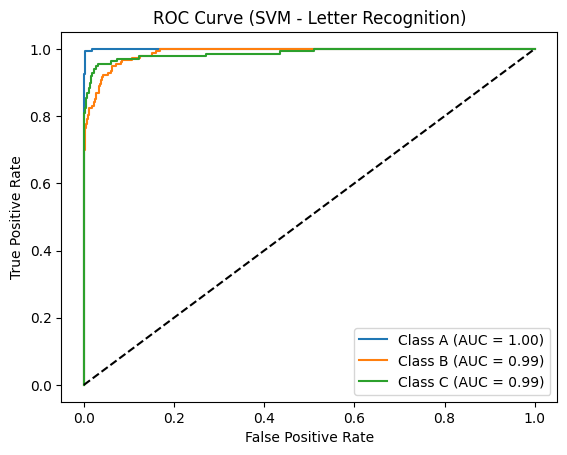

Average AUC Score: 0.9945338513091009


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"
data = pd.read_csv(url, header=None)



# Features and target
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Binarize labels for ROC
y_bin = label_binarize(y_encoded, classes=np.arange(26))

# Train-test split (80/20)
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    X, y_encoded, y_bin, test_size=0.2, random_state=42
)

# Train SVM model
model = OneVsRestClassifier(SVC(kernel='rbf', probability=True))
model.fit(X_train, y_train_bin)

# Predictions
y_pred_bin = model.predict(X_test)
y_pred = np.argmax(y_pred_bin, axis=1)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ROC and AUC
y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(26):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC for first 3 classes
plt.figure()

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {le.inverse_transform([i])[0]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SVM - Letter Recognition)")
plt.legend()
plt.show()

# Average AUC
print("Average AUC Score:", np.mean(list(roc_auc.values())))

In [7]:
data.shape

(20000, 17)